
<p style="font-size:50px">
<span style="font-size:200px">
&#9703;
</span>
Seaborn
</p>

---



La librairie [Seaborn](https://seaborn.pydata.org/) est une librairie de visualisation de graphiques statistiques construite sur Matplotlib.

Sous-sections :
[Présentation](#principe)&nbsp;|
[Visualisation de distributions](#distributions)&nbsp;|
[Visualisation de relations](#relations)&nbsp;|
[Exercices](#exercices)&nbsp;

<a id="distributions"></a>
### Présentation

Le but de seaborn est de fournir des fonctions pour produire rapidement les principaux types de graphiques statistiques (distributionnels, relationnels) à partir d'une DataFrame Pandas. 


Dans la suite, nous illustrerons les fonctionnalités de Seaborn sur les jeux de données `Breast Cancer Wisconsin` et `Iris` 

In [142]:
import pandas as pd
import seaborn as sns

features = ['id', 'clump', 'uniformity_cell_size', 'uniformity_cell_shape', 'marginal_adhesion','single_epithelial_cell_size', 'bare_nuclei', 'chromatin', 'normal_nucleoli', 'mitoses']
cls_att = 'class'
breast = pd.read_csv('../data/breast-cancer-wisconsin.data.with_null',names=features+[cls_att])
breast = breast.set_index('id')
breast = breast.dropna()

iris = sns.load_dataset('iris')

__Couleurs__

La fonction `color_palette` permet d'accéder aux [palettes de couleur](https://seaborn.pydata.org/tutorial/color_palettes.html) :

In [143]:
palette = sns.color_palette('Paired')
list(palette)

[(0.6509803921568628, 0.807843137254902, 0.8901960784313725),
 (0.12156862745098039, 0.47058823529411764, 0.7058823529411765),
 (0.6980392156862745, 0.8745098039215686, 0.5411764705882353),
 (0.2, 0.6274509803921569, 0.17254901960784313),
 (0.984313725490196, 0.6039215686274509, 0.6),
 (0.8901960784313725, 0.10196078431372549, 0.10980392156862745),
 (0.9921568627450981, 0.7490196078431373, 0.43529411764705883),
 (1.0, 0.4980392156862745, 0.0),
 (0.792156862745098, 0.6980392156862745, 0.8392156862745098),
 (0.41568627450980394, 0.23921568627450981, 0.6039215686274509),
 (1.0, 1.0, 0.6),
 (0.6941176470588235, 0.34901960784313724, 0.1568627450980392)]

In [144]:
palette

[(0.6509803921568628, 0.807843137254902, 0.8901960784313725),
 (0.12156862745098039, 0.47058823529411764, 0.7058823529411765),
 (0.6980392156862745, 0.8745098039215686, 0.5411764705882353),
 (0.2, 0.6274509803921569, 0.17254901960784313),
 (0.984313725490196, 0.6039215686274509, 0.6),
 (0.8901960784313725, 0.10196078431372549, 0.10980392156862745),
 (0.9921568627450981, 0.7490196078431373, 0.43529411764705883),
 (1.0, 0.4980392156862745, 0.0),
 (0.792156862745098, 0.6980392156862745, 0.8392156862745098),
 (0.41568627450980394, 0.23921568627450981, 0.6039215686274509),
 (1.0, 1.0, 0.6),
 (0.6941176470588235, 0.34901960784313724, 0.1568627450980392)]

In [145]:
sns.color_palette('icefire')

[(0.33355526, 0.64107876, 0.80445484),
 (0.28708711, 0.32912157, 0.69034504),
 (0.15652427, 0.15348248, 0.22238175),
 (0.22994394, 0.13076731, 0.15146314),
 (0.61319563, 0.1824336, 0.2687872),
 (0.91463791, 0.43668557, 0.21367954)]

__Thèmes__

Il y a 5 [thèmes prédéfinis](https://seaborn.pydata.org/tutorial/aesthetics.html) : `darkgrid`, `whitegrid`, `dark`, `white`, et `ticks` :

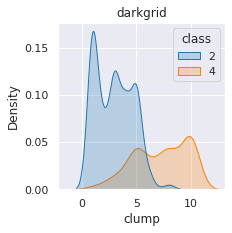

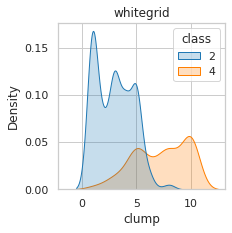

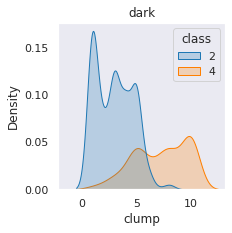

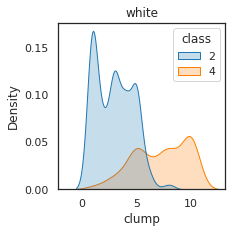

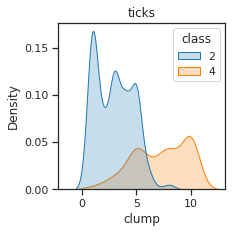

In [146]:
import matplotlib.pyplot as plt
colors = sns.color_palette('Paired')
(blue,orange) = (colors[1],colors[7])
for theme in ['darkgrid','whitegrid','dark','white','ticks']:
    with sns.axes_style(theme):
        plt.figure(figsize=(3,3),dpi=72)
        sns.kdeplot(breast,x='clump', hue='class', fill=True, palette=[blue,orange])
        plt.title(theme)
        plt.show()


__Interface fonctionnelle vs objet__

Le module `seaborn` propose :
- une __interface fonctionnelle__, qui contient une fonction pour chaque type de graphique :`displot()` pour les histogrammes, `boxplot()` pour les boîtes à moustache, `relplot()` pour les relations entre variables, etc.

<Axes: xlabel='clump', ylabel='Density'>

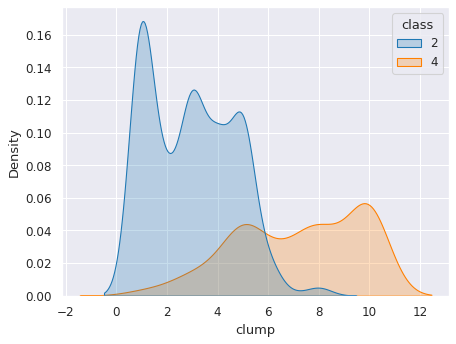

In [147]:
sns.set_theme(rc={'figure.figsize':(6.4,4.8),'figure.dpi':78})
sns.set_style('darkgrid')
sns.kdeplot(breast,x='clump', hue='class', fill=True, palette=[blue,orange])

- une __interface orientée objet__ (expérimentale), qui permet de faire la même chose en [manipulant des objets](https://seaborn.pydata.org/tutorial/objects_interface.html). Dans ce cas on crée d'abord un objet de type `Plot`, qui représente un graphique et est lié à une DataFrame Pandas, et ensuite on lui ajoute différentes couches de visualisation.

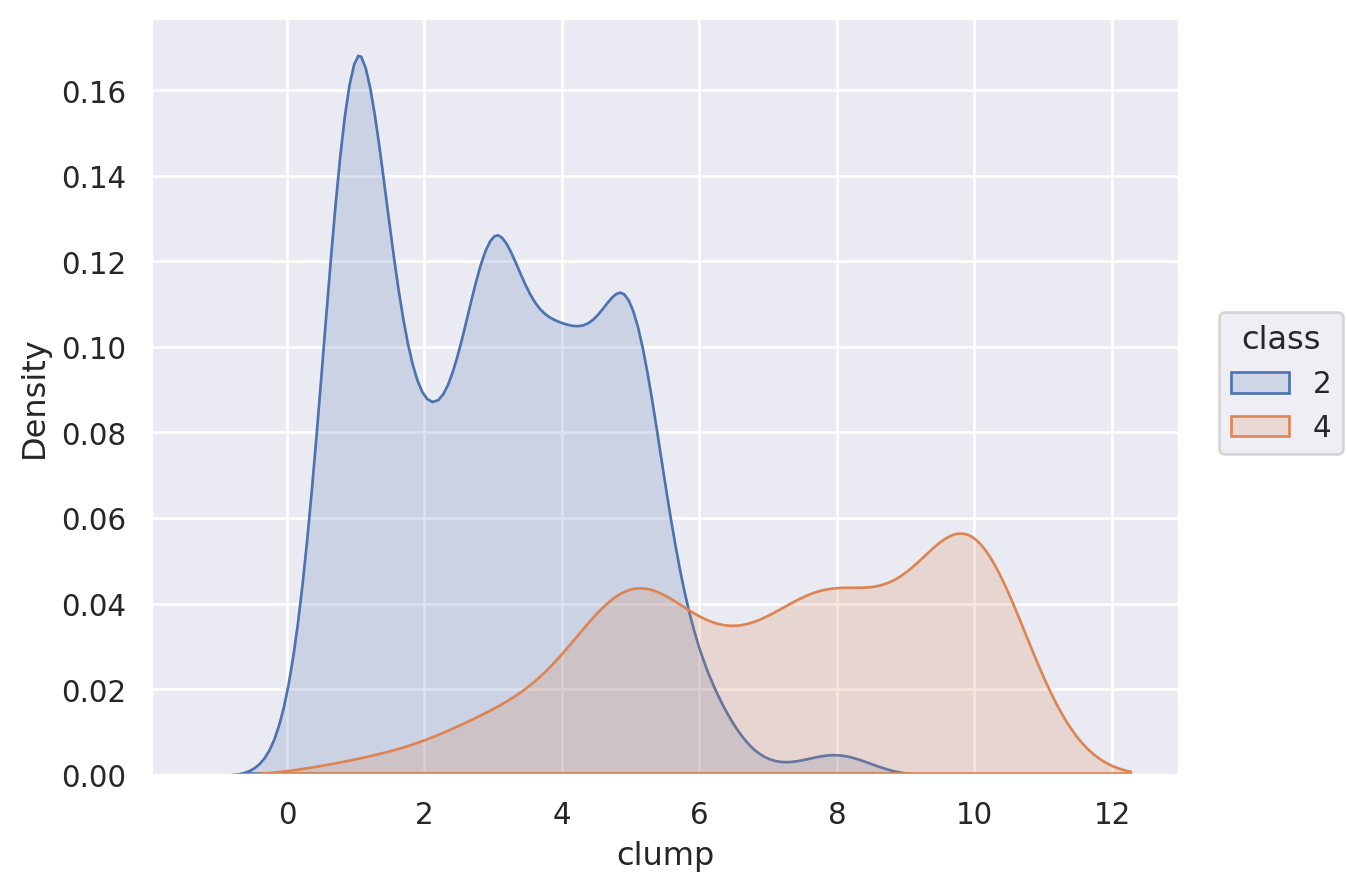

In [148]:
import seaborn.objects as so
sns.set_palette([blue,orange])
df_ = breast.copy()
df_['class'] = breast['class'].values.astype(str)
plot = so.Plot(df_, x='clump', color='class').label(y='Density')
plot.add(so.Area(),so.KDE())

<a id="distributions"></a>
### Visualisation de distributions

Seaborn propose pour visualiser des distributions de données :
- les fonctions `histplot`, `kdeplot`, `ecdfplot` et `rugplot` pour créer des sous-figures (histogrammes, estimation de densité, proportions cumulatives, etc.) ;
- les fonctions `displot`, `jointplot` et `pairplot` pour combiner ces sous-figures dans  des figures plus complexes qui intègrent plusieurs vues sur un même jeu de données.

On peut tracer des histogrammes pour voir la répartition d'un seule variable :

<Axes: xlabel='clump', ylabel='Count'>

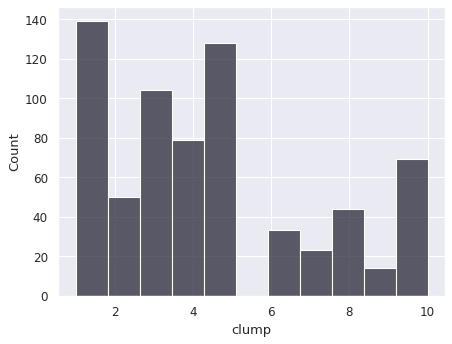

In [149]:
import seaborn as sns
ice = sns.color_palette('icefire')
sns.histplot(breast,x='clump',color=ice[2])

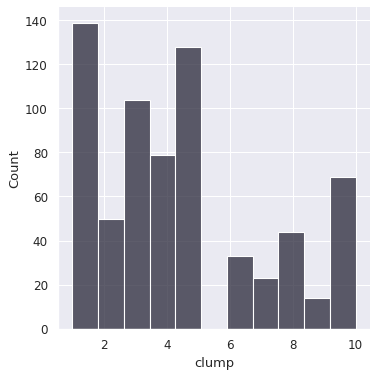

In [150]:
sns.displot(breast,x='clump',color=ice[2],kind="hist")

On peut générer un graphique pour chaque modalité d'une autre variable :

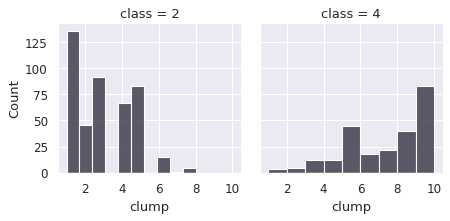

In [151]:
g = sns.FacetGrid(breast,col='class')
g.map(sns.histplot,'clump',color=ice[2])

ou afficher cette répartition sur un même graphique :

<Axes: xlabel='clump', ylabel='Count'>

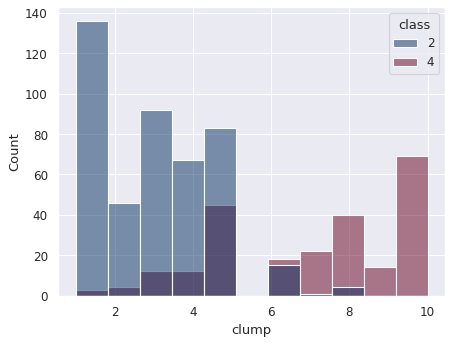

In [152]:
sns.histplot(breast,x='clump', hue="class", palette='RdBu_r')

On peut afficher une approximation continue de la densité de probabilité cet histogramme par Kernel Density Estimation :

<Axes: xlabel='clump', ylabel='Density'>

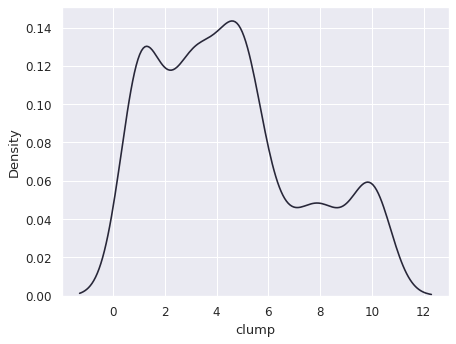

In [153]:
sns.kdeplot(breast,x='clump',color=ice[2])

<Axes: xlabel='clump', ylabel='Density'>

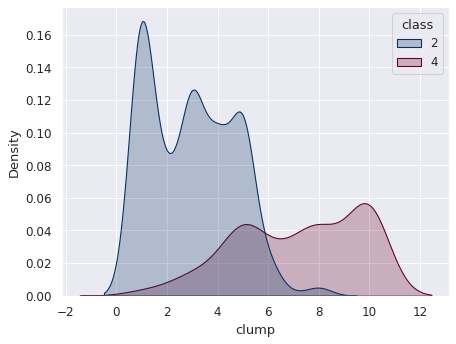

In [154]:
sns.kdeplot(breast,x='clump', hue="class", palette='RdBu_r', fill=True)

ou même de combiner les deux :

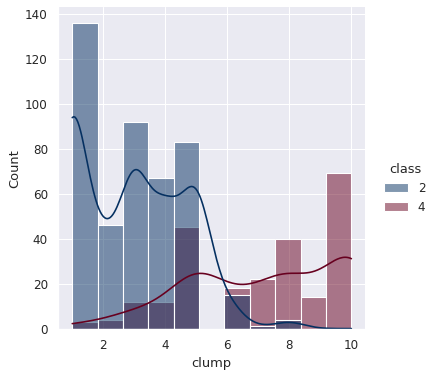

In [155]:
sns.displot(breast,x='clump', hue="class", palette='RdBu_r', kde=True)

<Axes: xlabel='clump', ylabel='Proportion'>

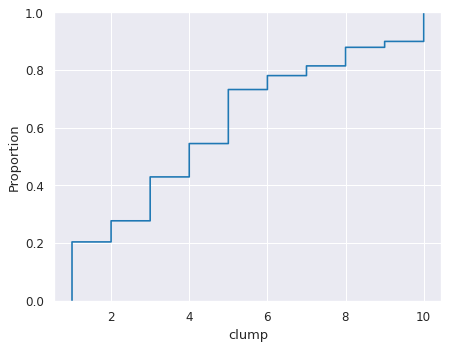

In [156]:
sns.ecdfplot(data=breast,x='clump')

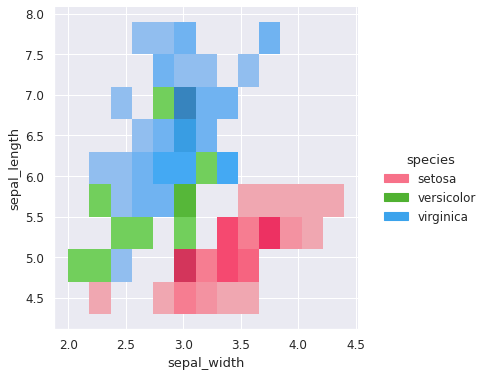

In [157]:
sns.displot(iris,x='sepal_width',y='sepal_length',hue='species')

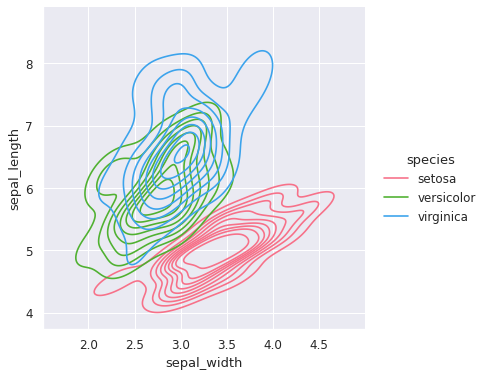

In [158]:
sns.displot(iris,x='sepal_width',y='sepal_length',hue='species', kind='kde')

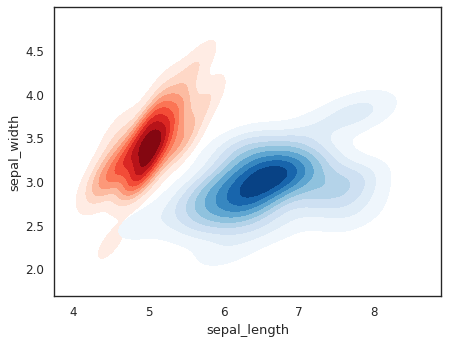

In [159]:
setosa = iris[iris['species'] == 'setosa']
virginica = iris[iris['species'] == 'virginica']
# ou sns.set_style('white')
with sns.axes_style('white'):
    sns.kdeplot(x=setosa['sepal_length'], y=setosa['sepal_width'], cmap ='Reds',fill=True)
    sns.kdeplot(x=virginica['sepal_length'], y=virginica['sepal_width'],  cmap ='Blues',fill=True)


<a id="relations"></a>
### Visualisation de relations

Au niveau figure, 
Seaborn propose deux fonctions génériques selon le type des variables : 
- `relplot` pour visualiser des [relations statistiques](https://seaborn.pydata.org/tutorial/relational.html) entre __deux variables numériques__
- `catplot` pour visualiser des [distributions par catégorie](https://seaborn.pydata.org/tutorial/categorical.html) si __au moins une des variables est catégorielle__

__Relations statistiques__

Pour visualiser des relations statistiques on peut utiliser :
- le fonction `scatterplot` (nuage de points) 
- la fonction `lineplot` (courbes d'évolution) 

Ces fonctions permettent de créer des sous-figures.

Au niveau figure, la fonction générique `relplot` rassemble ces deux fonctions en une même interface.

Par exemple 
```python
relplot(..., kind='scatter')
``` 
au niveau figure appellera la fonction `scatterplot` pour créer une sous-figure.

Par exemple :

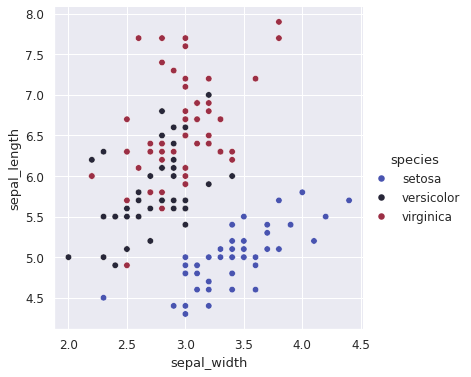

In [160]:
with sns.color_palette('icefire') as c:
    sns.relplot(data=iris,x='sepal_width',y='sepal_length',hue='species',palette=[c[1],c[2],c[4]], kind='scatter')

In [161]:
nat = pd.read_csv('../data/predictions.csv',sep=';')
nat.head()

,estimator,feature_selection,scenario,imbalance,bagging,test_type,sensitivity,accuracy,specificity,precision,...,fn_trouble_leger,sensitivity_trouble_majeur,accuracy_trouble_majeur,specificity_trouble_majeur,precision_trouble_majeur,f1_trouble_majeur,tp_trouble_majeur,fp_trouble_majeur,tn_trouble_majeur,fn_trouble_majeur
0,svm_rbf,logreg,dem,none,True,ibisc,0.412500,0.694856,0.847291,0.612027,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,svm_rbf,logreg,dem,none,True,cfx,0.611111,0.763918,0.848112,0.694444,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,svm_rbf,logreg,dem,none,True,motricite,0.476389,0.732734,0.869458,0.697192,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,svm_rbf,logreg,dem,none,True,best,0.608333,0.763390,0.847291,0.683150,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,svm_rbf,logreg,dem,none,True,all,0.586111,0.763214,0.858785,0.698232,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [162]:
df = nat.query('scenario == "dem" and test_type == "all"')
ss = pd.concat((pd.pivot_table(df,index='estimator',values='specificity',aggfunc='mean'),pd.pivot_table(df,index='estimator',values='sensitivity',aggfunc='mean')),axis=1)
ss

,specificity,sensitivity
estimator,,
3nn,0.855419,0.586806
5nn,0.847906,0.565278
7nn,0.849631,0.559028
logistic_regression,0.824713,0.537500
random_forest,0.847989,0.586389
svm_rbf,0.869540,0.638611
tree,0.799097,0.580000
xgboost,0.838670,0.547778


`scatterplot` (nuage de points)

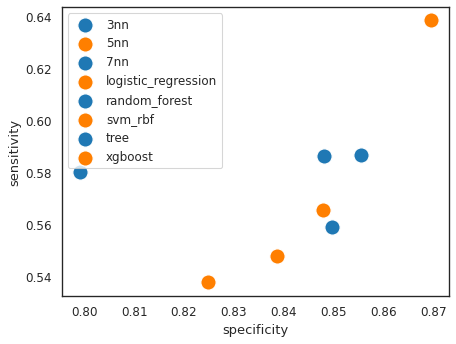

In [163]:
sns.set_style('white')
for estimator in ss.index:
    v = ss.loc[[estimator,],:]
    sns.scatterplot(data=v,x=v["specificity"],y=v['sensitivity'],label=estimator,s=200)


<Axes: >

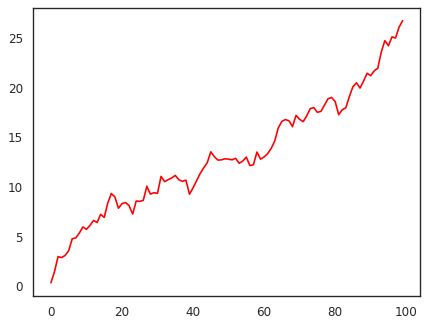

In [164]:
import numpy as np
sns.lineplot(np.cumsum(np.random.normal(0.3, 0.6, size=100)),color='red')

Plusieurs diagrammes en ligne peuvent être aggrégés sur une même figure.

On représente alors la moyenne et l'écart type des lignes obtenues.

Par exemple ici on aggrège 10 diagrammes (fold C0 à C9) :

In [165]:
N = 10
series = np.cumsum(np.random.normal(0.3, 0.6, size=(N,100)),axis=1) 
vals = pd.concat([pd.concat((pd.DataFrame(data=series[i],columns=['val']),pd.DataFrame(['C'+str(i)]*100,columns=['fold'])),axis=1) for i in range(N)],axis=0)
vals = vals.reset_index(names='x')
vals

,x,val,fold
0,0,0.636702,C0
1,1,1.279394,C0
2,2,2.160508,C0
3,3,2.244641,C0
4,4,2.445745,C0
...,...,...,...
995,95,34.970488,C9
996,96,34.096549,C9
997,97,33.616402,C9
998,98,33.969829,C9


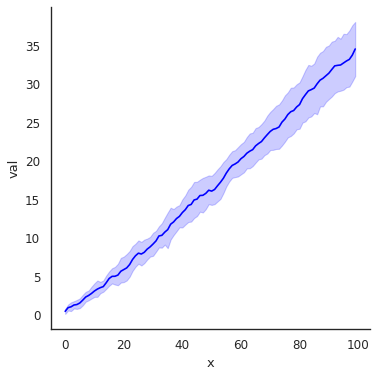

In [166]:
sns.relplot(data=vals,x='x', y='val',  kind='line', color='blue')

__Distributions par catégorie__

Pour visualiser des [distributions par catégorie](https://seaborn.pydata.org/tutorial/categorical.html) on peut utiliser :
- le fonction `stripplot` (dessine un nuage de points par catégorie) 
- la fonction `boxplot` (boites à moustache)
- la fonction `barplot` (histogramme)
- etc. 

Ces fonctions permettent de créer des sous-figures.

Au niveau figure, la fonction générique `catplot` rassemble ces fonctions en une même interface.

Par exemple 
```python
catplot(..., kind='bar')
``` 
au niveau figure appellera la fonction `barplot` pour créer une sous-figure.

Par exemple :

<Axes: xlabel='f1', ylabel='feature_selection'>

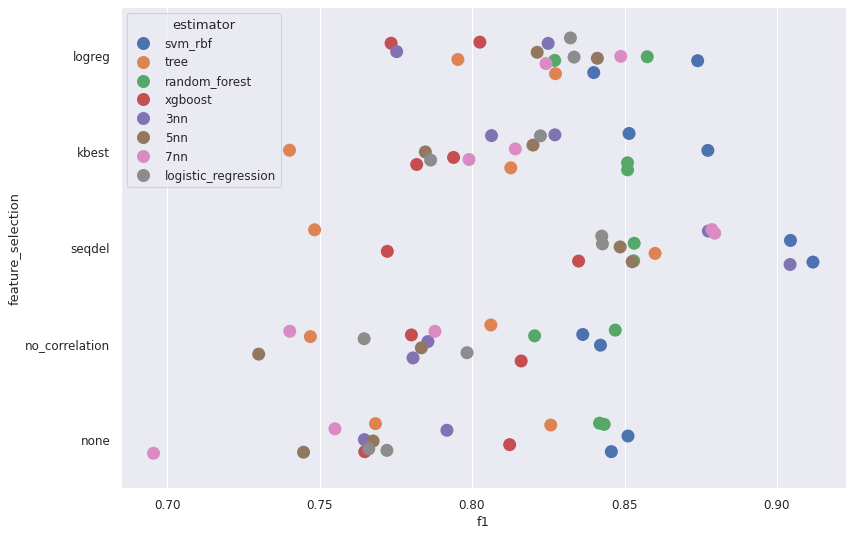

In [167]:
sns.set_theme(rc={'figure.figsize':(12,8)})
tb_cog = nat.query('scenario == "tb_cog" and test_type == "all"')
sns.stripplot(data=tb_cog,x='f1', y='feature_selection', hue='estimator', jitter=.2, size=12)

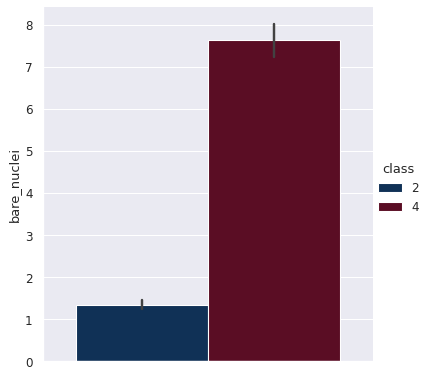

In [168]:
sns.catplot(breast,y='bare_nuclei', hue='class', kind='bar', palette='RdBu_r')

<Axes: ylabel='chromatin'>

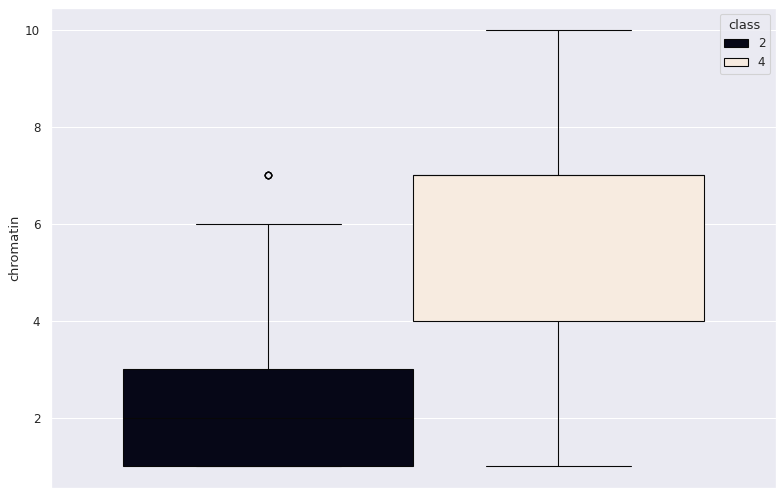

In [169]:
sns.boxplot(breast,y='chromatin',hue='class',palette='rocket')

<Axes: xlabel='estimator', ylabel='f1'>

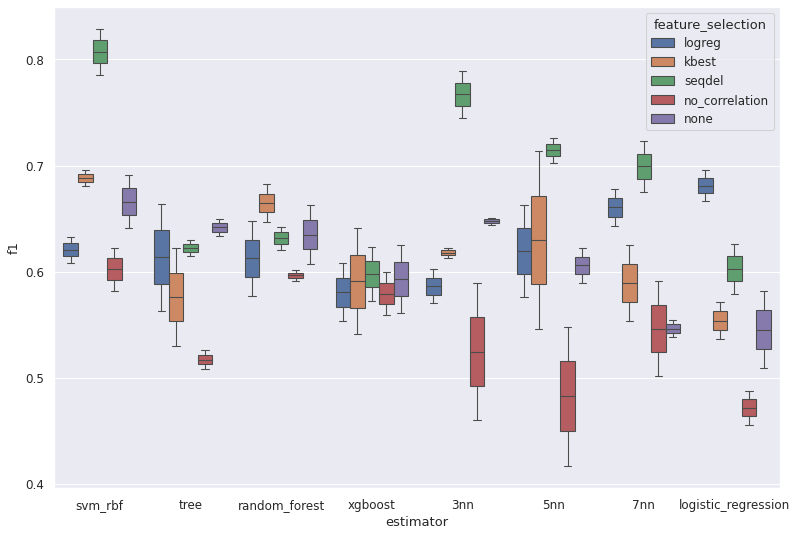

In [170]:
sns.set_theme(rc={'figure.figsize':(12,8)})
sns.boxplot(data=df,x='estimator', y='f1', hue='feature_selection')

<Axes: ylabel='chromatin'>

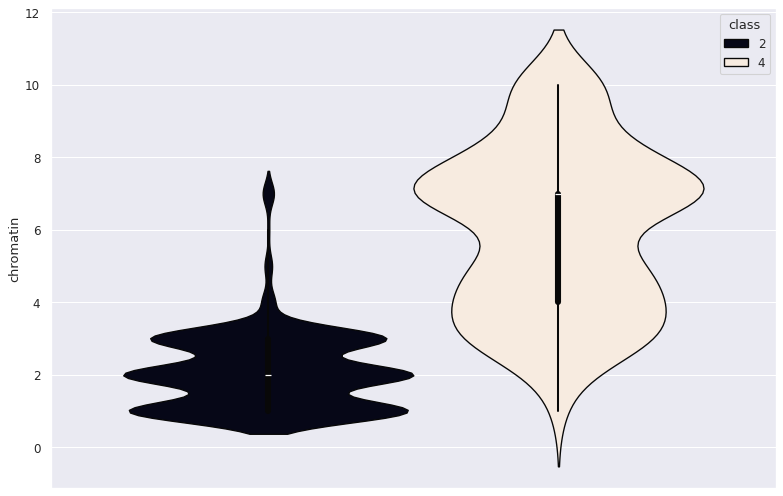

In [171]:
sns.violinplot(breast,y='chromatin',hue='class',palette='rocket')

<a id="relations"></a>
### Combiner plusieurs sous-figures

`JointPlot`

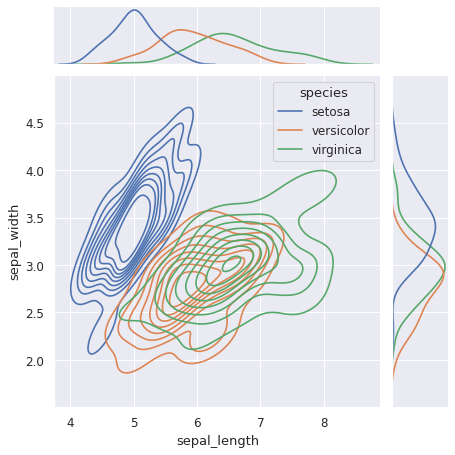

In [172]:
sns.jointplot(
    data=iris,
    x="sepal_length", y="sepal_width", hue="species",
    kind="kde"
)

`Pairplot`

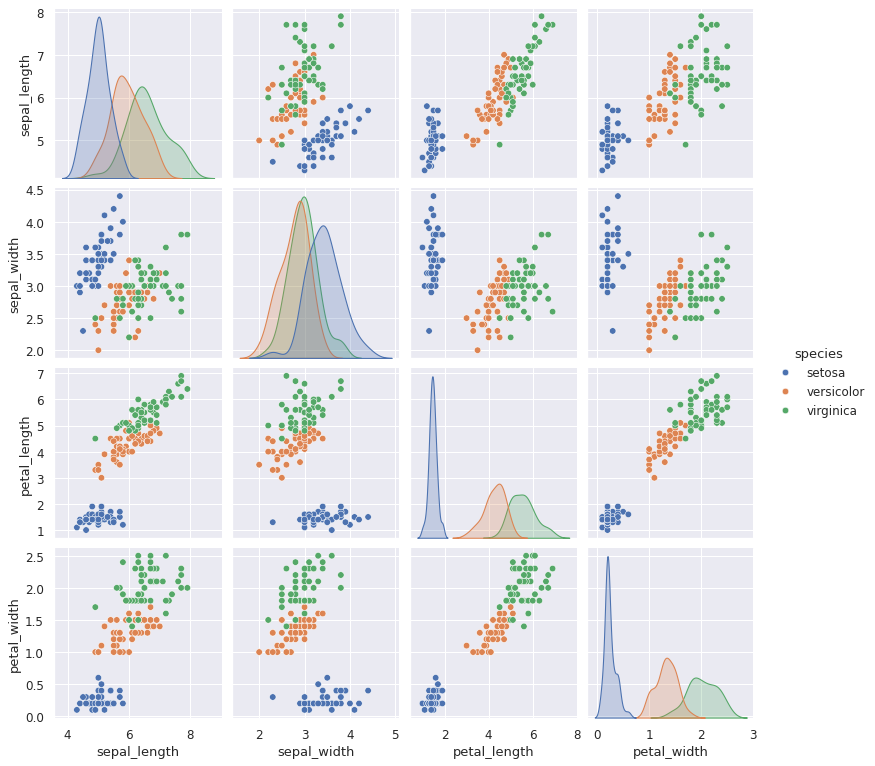

In [173]:
sns.pairplot(data=iris,hue='species')

`PairGrid`

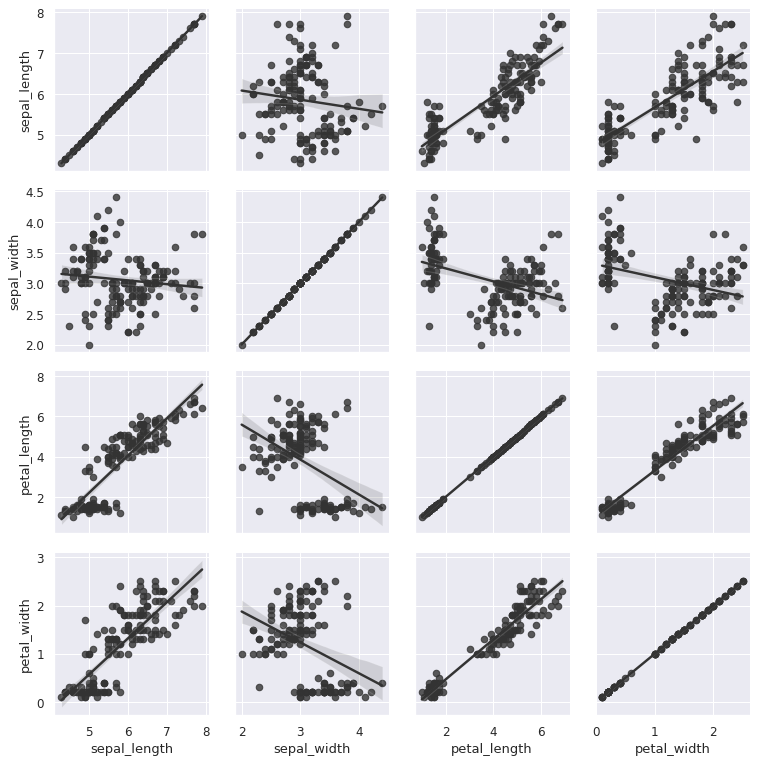

In [174]:
features = iris.columns[:-1]
sns.PairGrid(iris, y_vars=features, x_vars=features).map(sns.regplot,color='.2')

`FacetGrid`

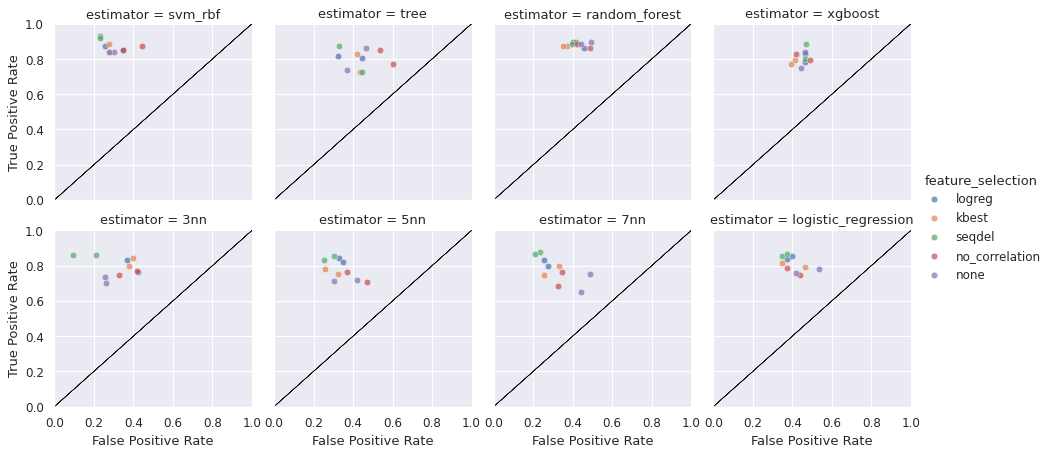

In [175]:
# Function to draw a vertical line
def draw_line(*args, **kwargs):
    for ax in g.axes.flat:
        ax.plot([0.,1.], color='black', linestyle='-',linewidth=.3, alpha=.2)

tb_cog = nat.query('scenario == "tb_cog" and test_type == "all"').copy()
tb_cog['fpr'] = np.ones(len(tb_cog)) - tb_cog['specificity'].values
g = sns.FacetGrid(tb_cog, hue='feature_selection',col='estimator',col_wrap=4)
g.map(sns.scatterplot, 'fpr', 'sensitivity',alpha=.7)
g.map(draw_line)
g.set_xlabels('False Positive Rate')
g.set_ylabels('True Positive Rate')
g.set(xlim=(0, 1))
g.set(ylim=(0, 1))
g.add_legend()

Combiner des sous-figures avec Matplotlib

<Axes: xlabel='petal_length', ylabel='sepal_length'>

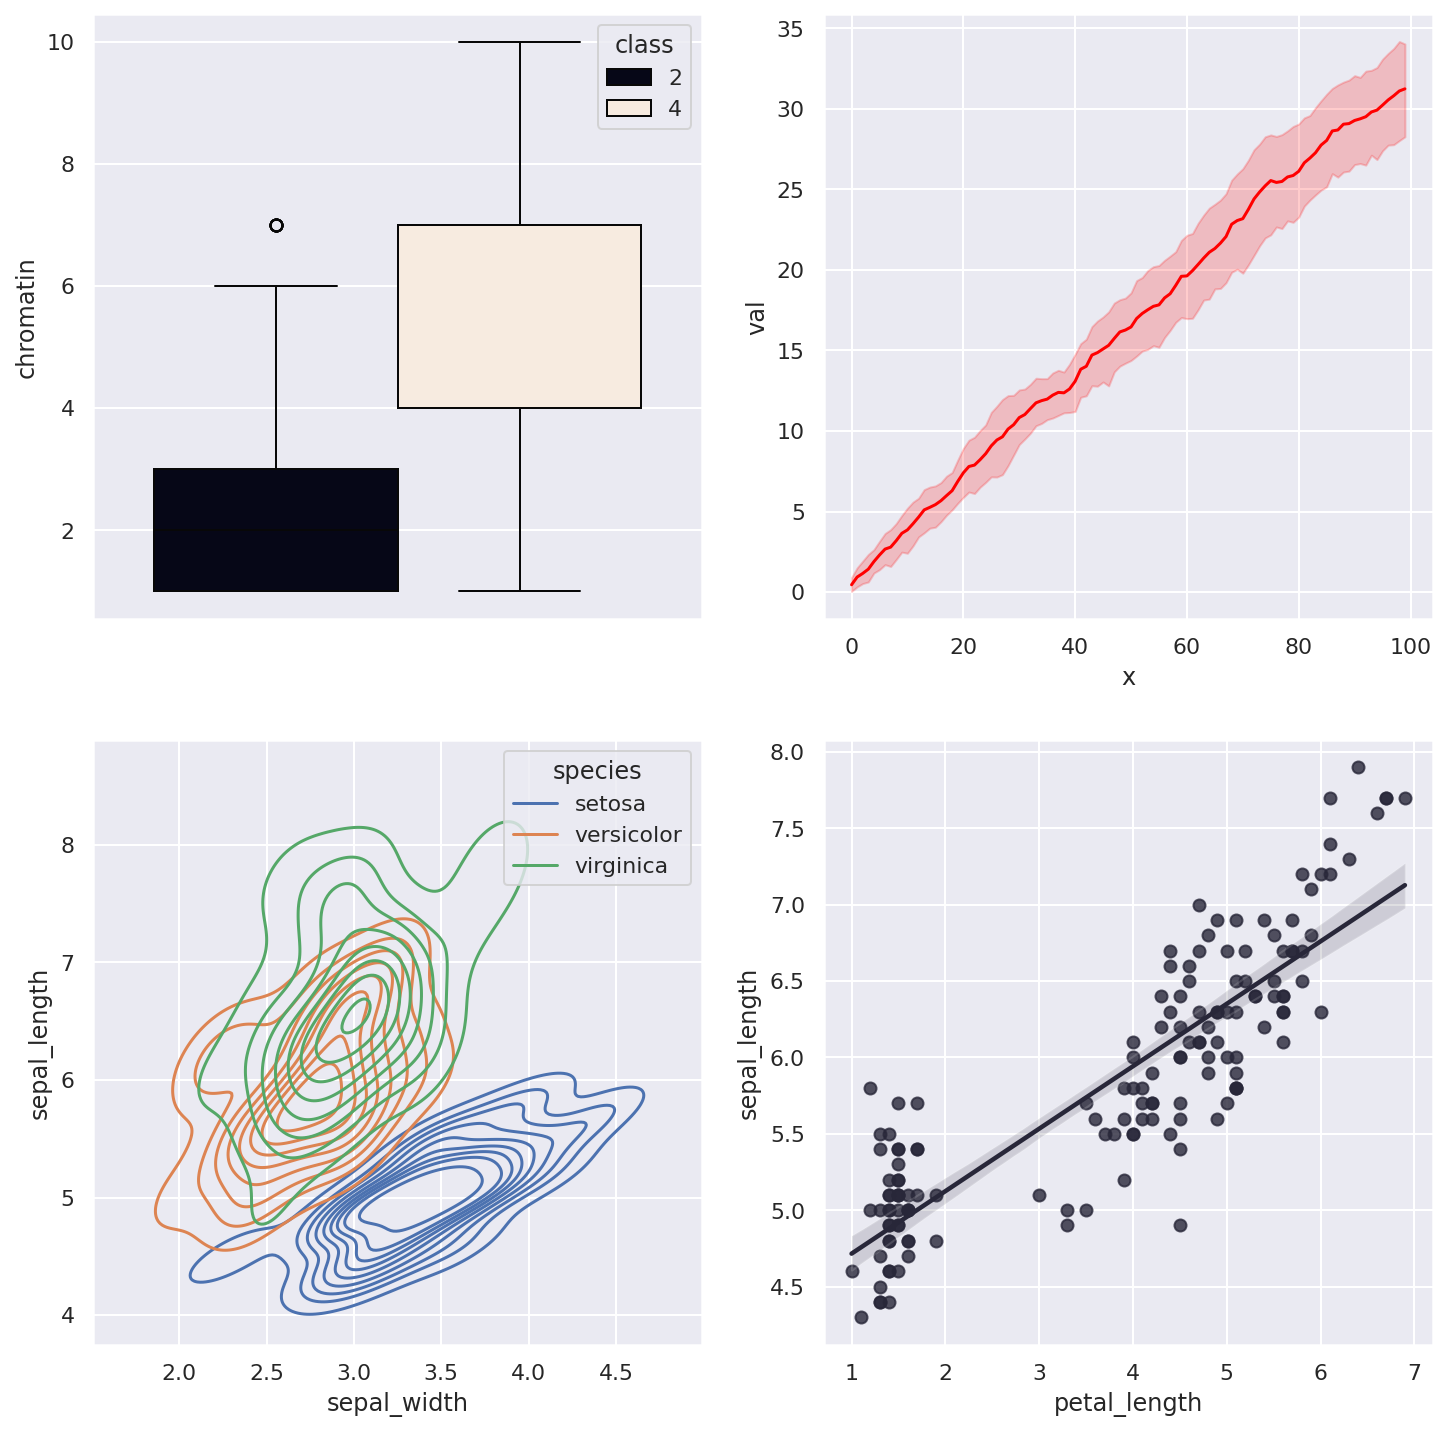

In [176]:
fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(12,12), dpi=144)
sns.boxplot(ax=axs[0,0],data=breast,y='chromatin',hue='class',palette='rocket')
N = 10
series = np.cumsum(np.random.normal(0.3, 0.6, size=(N,100)),axis=1) 
vals = pd.concat([pd.concat((pd.DataFrame(data=series[i],columns=['val']),pd.DataFrame(['C'+str(i)]*100,columns=['fold'])),axis=1) for i in range(N)],axis=0)
vals = vals.reset_index(names='x')
sns.lineplot(ax=axs[0,1],data=vals,x='x', y='val', color='red')
sns.kdeplot(ax=axs[1,0],data=iris,x='sepal_width',y='sepal_length',hue='species')
colors = sns.color_palette('icefire')
sns.regplot(ax=axs[1,1],data=iris, x='petal_length',y='sepal_length', color=colors[2])


---

<a id="exercices"></a>
### Exercices

In [177]:
import matplotlib.pyplot as plt
import seaborn as sns
iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


A l'aide de la fonction `histplot` (ou `displot`), tracer la distribution de l'attribut `sepal_width` du jeu de données Iris.

<Axes: xlabel='sepal_width', ylabel='Count'>

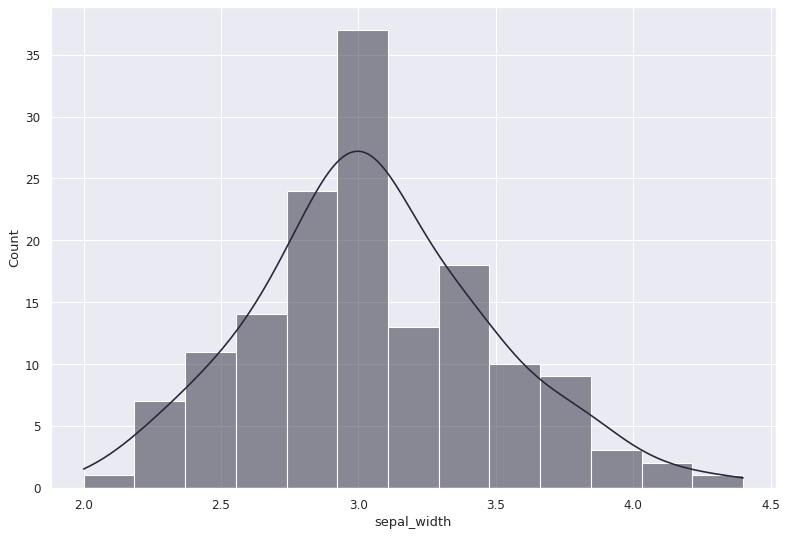

In [183]:
# <- completer ici
sns.histplot(iris,x='sepal_width', color=ice[2], kde=True)

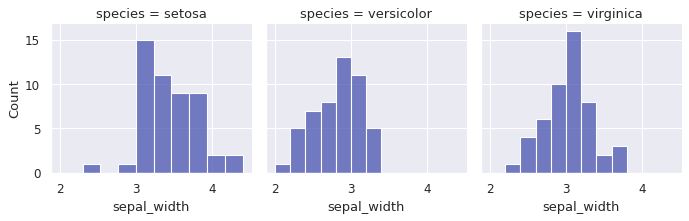

In [182]:
g = sns.FacetGrid(iris,col='species')
g.map(sns.histplot,'sepal_width',color=ice[1])

A l'aide de la fonction `sns.boxplot()`, tracer les diagrammes à moustache de l'attribut sepal_width pour tout le jeu de données, puis par espèce.

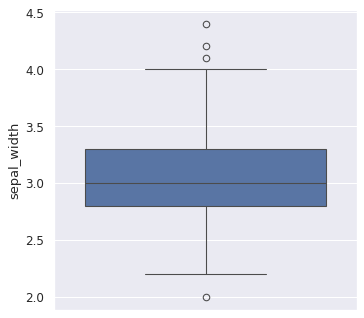

In [180]:
# <- completer ici
plt.figure(figsize=(5,5))
plt.tight_layout()
box = sns.boxplot(data=iris,y='sepal_width')

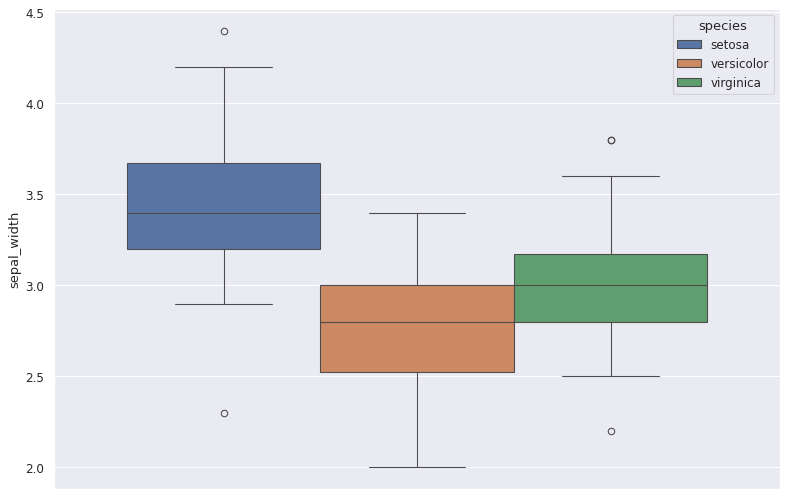

In [181]:
box_species = sns.boxplot(data=iris,y='sepal_width',hue='species')